# SSM Robustness Evaluation

Compares **Mamba** (SSM) against **GPT-2** and a **Linear Transformer** on robustness to label noise, context bloat, and adversarial text perturbations.

| # | Experiment | Models |
|---|-----------|--------|
| 1 | Outlier fraction sweep: accuracy vs corrupted label fraction | TheoreticalMamba vs LinearTransformer |
| 2 | Perplexity vs sequence length | GPT-2 vs Mamba-370M |
| 3 | Context-window stuffing: accuracy vs prepended filler tokens | GPT-2 vs Mamba-370M |
| 4 | Prompt injection & disruption: adversarial prefix/label attacks | GPT-2 vs Mamba-370M |


### Setup

Standard imports and global constants. `DEVICE` is set to CUDA if available, otherwise CPU. `OUTDIR` points to the `outputs/` folder where results and checkpoints are saved.

In [1]:
from __future__ import annotations

import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

OUTDIR = Path("outputs")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)


device: cuda


### Plotting utilities

`plot_lines` renders multiple named series as line charts. Pass `log_x=True` for log-scale x-axis (used in Exp 2).

In [2]:
def plot_lines(series: dict, xlabel: str, ylabel: str, title: str, log_x: bool = False):
    fig, ax = plt.subplots(figsize=(7, 4))
    for name, kv in series.items():
        ax.plot(list(kv.keys()), list(kv.values()), marker="o", label=name)
    ax.set(xlabel=xlabel, ylabel=ylabel, title=title)
    if log_x:
        ax.set_xscale("log")
    ax.legend()
    plt.tight_layout()
    plt.show()


### ICL task & batch builder

`BinaryICLTask` generates a synthetic binary classification task: samples $x \sim \mathcal{N}(\pm\mu, I)$ with a fixed unit vector $\mu$.

`build_batch` assembles a batch of prompt matrices $P \in \mathbb{R}^{(d+1)\times(l+1)}$ where each column is a context token $[x_i;\,y_i]$ and the last column is the query $[x_q;\,0]$. Corrupts a fraction of context labels according to the chosen `outlier_mode`.

In [3]:
class BinaryICLTask:
    def __init__(self, d: int, device: str = "cpu"):
        self.d = d
        self.device = device
        mu = torch.randn(d, device=device)
        self.mu = mu / mu.norm()

    def sample(self, n: int, snr: float = 3.0):
        noise = torch.randn(n, self.d, device=self.device)
        s = torch.randint(0, 2, (n,), device=self.device).float() * 2 - 1
        return noise + s.unsqueeze(-1) * self.mu * snr, s


def build_batch(
    tasks,
    n_ctx: int,
    outlier_frac: float,
    bsz: int,
    device: str,
    outlier_mode: str = "flip",
):
    Ps, labs, ys = [], [], []
    for _ in range(bsz):
        task = random.choice(tasks)
        x_c, y_c = task.sample(n_ctx)
        if outlier_frac > 0:
            n_out = max(1, int(n_ctx * outlier_frac))
            idx = torch.randperm(n_ctx)[:n_out]
            if outlier_mode == "flip":
                y_c[idx] *= -1
            elif outlier_mode == "targeted":
                y_c[idx] = -1.0
            else:
                y_c[idx] = (
                    torch.randint(0, 2, (n_out,), device=task.device).float() * 2 - 1
                )
        x_q, y_q = task.sample(1)
        ctx = torch.cat([x_c.T, y_c.unsqueeze(0)], 0)
        qcol = torch.cat([x_q.T, torch.zeros(1, 1, device=task.device)], 0)
        P = torch.cat([ctx, qcol], -1).to(device)
        labels = torch.cat([y_c, torch.zeros(1, device=task.device)]).to(device)
        Ps.append(P)
        labs.append(labels)
        ys.append(y_q[0].item())
    return (
        torch.stack(Ps),
        torch.stack(labs),
        torch.tensor(ys, dtype=torch.float32, device=device),
    )


### Evaluation helpers

- **`eval_icl`** runs ICL accuracy on synthetic tasks; runs `n_trials` examples in batches of 128, predicts via `sign(output)`.
- **`eval_fewshot`** n-shot SST-2 sentiment accuracy; compares $\log P(\texttt{ positive})$ vs $\log P(\texttt{ negative})$ at the last generated token.
- **`eval_ppl_vs_length`** per-length perplexity on a text list; truncates each text to exactly $L$ tokens, computes $\exp\!\left(\tfrac{1}{T}\sum_t \mathcal{L}_t\right)$ over non-padding tokens.

In [4]:
@torch.no_grad()
def eval_icl(
    model,
    tasks,
    n_ctx: int,
    outlier_frac: float,
    n_trials: int,
    device: str,
    outlier_mode: str = "flip",
) -> float:
    model.eval()
    model.to(device)
    correct = total = 0
    while total < n_trials:
        bsz = min(128, n_trials - total)
        P, labels, y_true = build_batch(
            tasks, n_ctx, outlier_frac, bsz, device, outlier_mode
        )
        pred = model(P, labels).sign()
        pred[pred == 0] = 1.0
        correct += (pred == y_true).sum().item()
        total += bsz
    return correct / total


@torch.no_grad()
def eval_fewshot(
    model,
    tokenizer,
    test_pairs: list,
    demo_pairs: list,
    n_shots: int,
    device: str,
    batch_size: int = 32,
) -> float:
    model.eval()
    pos_id = tokenizer(" positive", return_tensors="pt").input_ids[0, 0].item()
    neg_id = tokenizer(" negative", return_tensors="pt").input_ids[0, 0].item()
    lmap = {0: "negative", 1: "positive"}

    prompts, true_labels = [], []
    for text, true_lbl in test_pairs:
        demos = random.sample(demo_pairs, min(n_shots, len(demo_pairs)))
        prompt = (
            "".join(f"Review: {t[:120]}\nSentiment: {lmap[l]}\n\n" for t, l in demos)
            + f"Review: {text[:120]}\nSentiment:"
        )
        prompts.append(prompt)
        true_labels.append(true_lbl)

    correct = 0
    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i : i + batch_size]
        batch_true = true_labels[i : i + batch_size]
        enc = tokenizer(
            batch_prompts,
            return_tensors="pt",
            truncation=True,
            max_length=1024,
            padding=True,
        ).to(device)
        logits = model(**enc).logits
        last_idx = enc["attention_mask"].sum(dim=1) - 1
        brange = torch.arange(len(batch_prompts), device=device)
        preds = (
            logits[brange, last_idx, pos_id] > logits[brange, last_idx, neg_id]
        ).long()
        correct += (preds == torch.tensor(batch_true, device=device)).sum().item()
    return correct / len(test_pairs)


@torch.no_grad()
def eval_ppl_vs_length(
    wrapper,
    texts: list,
    tokenizer,
    lengths: list,
    device: str,
    label: str = "",
    batch_size: int = 16,
) -> dict:
    vocab = wrapper.model.config.vocab_size
    results = {}
    for L in lengths:
        _trunc = lambda t: tokenizer.decode(
            tokenizer(t, return_tensors="pt").input_ids[0][:L], skip_special_tokens=True
        )
        chunks = [_trunc(t) for t in texts if len(_trunc(t).split()) >= 5]
        if not chunks:
            results[L] = float("inf")
            continue
        ppls = []
        for i in range(0, len(chunks), batch_size):
            enc = tokenizer(
                chunks[i : i + batch_size],
                return_tensors="pt",
                truncation=True,
                max_length=L + 32,
                padding=True,
            ).to(device)
            ids, mask = enc["input_ids"], enc["attention_mask"]
            logits = wrapper.model(ids, attention_mask=mask).logits
            shift_logits = logits[:, :-1].contiguous()
            shift_labels = ids[:, 1:].contiguous()
            shift_labels[mask[:, 1:] == 0] = -100
            B, T = shift_labels.shape
            loss = F.cross_entropy(
                shift_logits.reshape(-1, vocab),
                shift_labels.reshape(-1),
                ignore_index=-100,
                reduction="none",
            ).reshape(B, T)
            valid_tokens = (shift_labels != -100).float().sum(dim=1)
            per_sample_nll = loss.sum(dim=1) / valid_tokens.clamp(min=1)
            for ppl in per_sample_nll.exp().tolist():
                if math.isfinite(ppl):
                    ppls.append(ppl)
        results[L] = sum(ppls) / len(ppls) if ppls else float("inf")
        tag = f"[{label}] " if label else ""
        print(f"{tag}L={L:5d} PPL={results[L]:.3f} (n={len(ppls)})", flush=True)
    return results


## Exp 1 Outlier Fraction Sweep

Train one-layer Mamba and Linear Transformer on a synthetic binary ICL task. Sweep outlier fraction 0->0.9 under three label-corruption modes (`flip`, `targeted`, `random`) and compare accuracy.


exp 1 - outlier fraction sweep
training mamba...
step 600 loss=0.8933
step 1200 loss=0.4204
step 1800 loss=0.5290
step 2400 loss=0.9795
step 3000 loss=0.5186
training linear transformer...
step 600 loss=0.0000
step 1200 loss=0.0059
step 1800 loss=0.0329
step 2400 loss=0.0000
step 3000 loss=0.0000
mode: flip


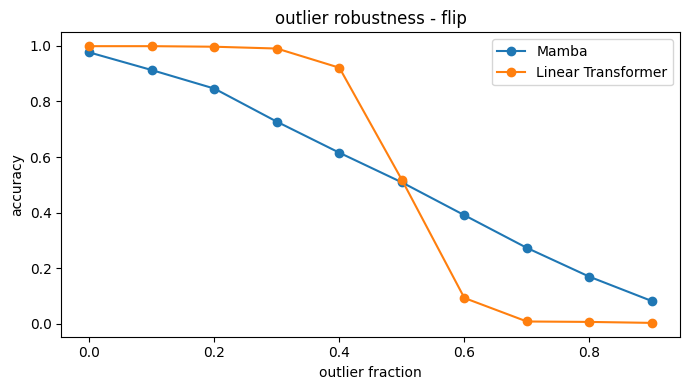

0.0 mamba=0.9760 lintf=0.9985
0.1 mamba=0.9125 lintf=0.9985
0.2 mamba=0.8460 lintf=0.9965
0.3 mamba=0.7270 lintf=0.9900
0.4 mamba=0.6155 lintf=0.9210
0.5 mamba=0.5090 lintf=0.5180
0.6 mamba=0.3910 lintf=0.0935
0.7 mamba=0.2735 lintf=0.0090
0.8 mamba=0.1700 lintf=0.0075
0.9 mamba=0.0825 lintf=0.0040
mode: targeted


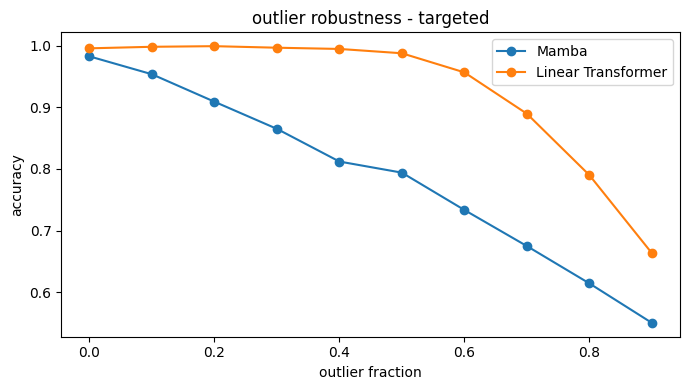

0.0 mamba=0.9825 lintf=0.9955
0.1 mamba=0.9535 lintf=0.9980
0.2 mamba=0.9090 lintf=0.9990
0.3 mamba=0.8650 lintf=0.9965
0.4 mamba=0.8120 lintf=0.9945
0.5 mamba=0.7940 lintf=0.9875
0.6 mamba=0.7335 lintf=0.9565
0.7 mamba=0.6750 lintf=0.8895
0.8 mamba=0.6145 lintf=0.7900
0.9 mamba=0.5505 lintf=0.6635
mode: random


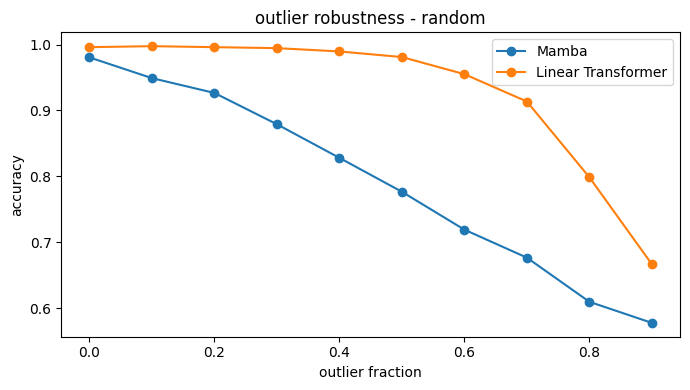

0.0 mamba=0.9805 lintf=0.9960
0.1 mamba=0.9490 lintf=0.9975
0.2 mamba=0.9265 lintf=0.9960
0.3 mamba=0.8790 lintf=0.9945
0.4 mamba=0.8280 lintf=0.9895
0.5 mamba=0.7765 lintf=0.9810
0.6 mamba=0.7190 lintf=0.9550
0.7 mamba=0.6765 lintf=0.9135
0.8 mamba=0.6095 lintf=0.7985
0.9 mamba=0.5775 lintf=0.6665


In [5]:
from src.models.mamba_theoretical import TheoreticalMamba
from src.models.linear_transformer import LinearTransformer

D, N_CTX = 16, 20
FRACS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
MODES = ["flip", "targeted", "random"]

print("exp 1 - outlier fraction sweep")
tasks_tr = [BinaryICLTask(D, DEVICE) for _ in range(200)]
tasks_te = [BinaryICLTask(D, DEVICE) for _ in range(50)]


def train(model, n_iters: int = 3000):
    model.to(DEVICE).train()
    opt = torch.optim.SGD(model.parameters(), lr=0.01)
    for step in range(n_iters):
        frac = random.uniform(0.0, 0.5)
        P, labels, y_true = build_batch(tasks_tr, N_CTX, frac, 64, DEVICE)
        opt.zero_grad()
        loss = torch.clamp(1.0 - y_true * model(P, labels), min=0.0).mean()
        loss.backward()
        opt.step()
        if (step + 1) % 600 == 0:
            print(f"step {step+1} loss={loss.item():.4f}")


mamba = TheoreticalMamba(D)
lintfm = LinearTransformer(D)
print("training mamba...")
train(mamba)
print("training linear transformer...")
train(lintfm)

(OUTDIR / "results").mkdir(parents=True, exist_ok=True)
torch.save(mamba.state_dict(), OUTDIR / "results/mamba_theoretical.pt")
torch.save(lintfm.state_dict(), OUTDIR / "results/linear_transformer.pt")

for mode in MODES:
    print(f"mode: {mode}")
    results = {}
    for name, model in [("Mamba", mamba), ("Linear Transformer", lintfm)]:
        results[name] = {
            f: eval_icl(model, tasks_te, N_CTX, f, 2000, DEVICE, mode) for f in FRACS
        }
    plot_lines(results, "outlier fraction", "accuracy", f"outlier robustness - {mode}")
    for f in FRACS:
        print(
            f"{f:.1f} mamba={results['Mamba'][f]:.4f} lintf={results['Linear Transformer'][f]:.4f}"
        )

## Exp 2 Perplexity vs Sequence Length

Measure WikiText-103 perplexity for GPT-2 and Mamba-370M across lengths 64->4096 tokens. Detect the first length where Mamba PPL diverges from GPT-2 by >15%.


exp 2 - perplexity vs sequence length


30 texts


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 3050.51it/s]
[transformers] The fast path is not available because one of `(selective_state_update, selective_scan_fn, causal_conv1d_fn, causal_conv1d_update, mamba_inner_fn)` is None. Falling back to the sequential implementation of Mamba, as use_mambapy is set to False. To install follow https://github.com/state-spaces/mamba/#installation for mamba-ssm and install the kernels library using `pip install kernels` or https://github.com/Dao-AILab/causal-conv1d for causal-conv1d. For the mamba.py backend, follow https://github.com/alxndrTL/mamba.py.
Loading weights: 100%|██████████| 482/482 [00:00<00:00, 3542.98it/s]


evaluating gpt-2...
[gpt2] L=   64 PPL=76.678 (n=30)
[gpt2] L=  128 PPL=65.196 (n=30)
[gpt2] L=  256 PPL=59.758 (n=30)
[gpt2] L=  512 PPL=59.758 (n=30)
[gpt2] L= 1024 PPL=59.758 (n=30)
[gpt2] L= 2048 PPL=59.758 (n=30)
[gpt2] L= 4096 PPL=59.758 (n=30)
evaluating mamba-370m...
[mamba] L=   64 PPL=42.742 (n=30)
[mamba] L=  128 PPL=36.688 (n=30)
[mamba] L=  256 PPL=33.842 (n=30)
[mamba] L=  512 PPL=33.842 (n=30)
[mamba] L= 1024 PPL=33.842 (n=30)
[mamba] L= 2048 PPL=33.842 (n=30)
[mamba] L= 4096 PPL=33.842 (n=30)
no break-point


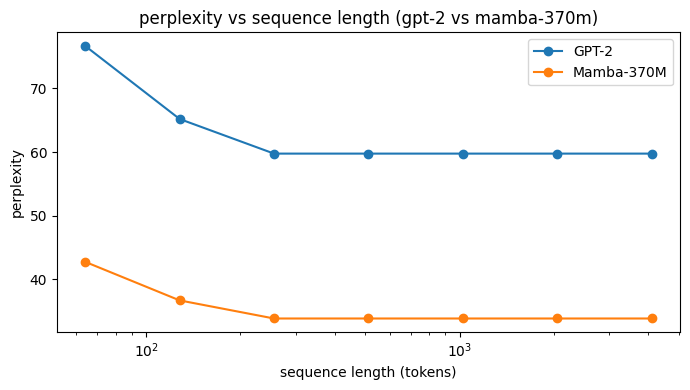

L=   64 gpt2=  76.678 mamba=  42.742
L=  128 gpt2=  65.196 mamba=  36.688
L=  256 gpt2=  59.758 mamba=  33.842
L=  512 gpt2=  59.758 mamba=  33.842
L= 1024 gpt2=  59.758 mamba=  33.842
L= 2048 gpt2=  59.758 mamba=  33.842
L= 4096 gpt2=  59.758 mamba=  33.842


In [6]:
from src.models.gpt2_model import GPT2PPLWrapper, load_gpt2, load_gpt2_tokenizer
from src.models.mamba_nlp import MambaNLPWrapper, load_mamba, load_mamba_tokenizer
from datasets import load_dataset

LENGTHS = [64, 128, 256, 512, 1024, 2048, 4096]
MAX_TEXTS = 30
print("exp 2 - perplexity vs sequence length")

texts = [
    r["text"].strip()
    for r in load_dataset("wikitext", "wikitext-103-raw-v1", split="test")
    if len(r["text"].strip()) > 100
][:MAX_TEXTS]
print(f"{len(texts)} texts")

gpt2 = load_gpt2("gpt2", DEVICE)
gpt2_tok = load_gpt2_tokenizer("gpt2")
gpt2_w = GPT2PPLWrapper(gpt2, gpt2_tok)

mamba = load_mamba(device=DEVICE)
mamba_tok = load_mamba_tokenizer()
mamba_w = MambaNLPWrapper(mamba, mamba_tok)

print("evaluating gpt-2...")
results = {
    "GPT-2": eval_ppl_vs_length(gpt2_w, texts, gpt2_tok, LENGTHS, DEVICE, "gpt2")
}
print("evaluating mamba-370m...")
results["Mamba-370M"] = eval_ppl_vs_length(
    mamba_w, texts, mamba_tok, LENGTHS, DEVICE, "mamba"
)

bp = None
for L in LENGTHS:
    m_ppl, g_ppl = results["Mamba-370M"][L], results["GPT-2"][L]
    if math.isfinite(m_ppl) and math.isfinite(g_ppl) and m_ppl > g_ppl * 1.15:
        bp = L
        break
print(f"break-point: L={bp}" if bp else "no break-point")

plot_lines(
    results,
    "sequence length (tokens)",
    "perplexity",
    "perplexity vs sequence length (gpt-2 vs mamba-370m)",
    log_x=True,
)

for L in LENGTHS:
    print(
        f"L={L:5d} gpt2={results['GPT-2'][L]:8.3f} mamba={results['Mamba-370M'][L]:8.3f}"
    )

## Exp 3 Context-Window Stuffing

Prepend 0->400 random filler tokens to SST-2 inputs and measure 4-shot accuracy degradation for GPT-2 vs Mamba-370M.


exp 3 - context stuffing


Loading weights: 100%|██████████| 482/482 [00:00<00:00, 4002.51it/s]


n=   0 gpt2=0.5900 mamba=0.6500
n=  50 gpt2=0.4300 mamba=0.5500
n= 100 gpt2=0.4900 mamba=0.4700
n= 150 gpt2=0.4500 mamba=0.5300
n= 200 gpt2=0.4500 mamba=0.4900
n= 250 gpt2=0.4200 mamba=0.5500
n= 300 gpt2=0.4900 mamba=0.4400
n= 350 gpt2=0.5100 mamba=0.4500
n= 400 gpt2=0.4600 mamba=0.5500


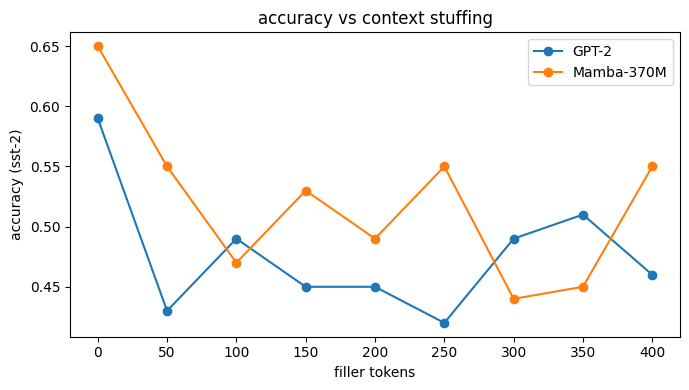

In [7]:
from datasets import load_dataset
from src.models.gpt2_model import load_gpt2, load_gpt2_tokenizer
from src.models.mamba_nlp import load_mamba, load_mamba_tokenizer
from src.perturbations import stuff

STEP = 50
N_TEST = 100

print("exp 3 - context stuffing")
all_pairs = [
    (r["sentence"], r["label"])
    for r in load_dataset("glue", "sst2", split="validation", trust_remote_code=True)
][:N_TEST + 200]
test_pairs = all_pairs[:N_TEST]
train_pairs = all_pairs[N_TEST:]

gpt2 = load_gpt2("gpt2", DEVICE)
gpt2_tok = load_gpt2_tokenizer("gpt2")
mamba = load_mamba(device=DEVICE)
mamba_tok = load_mamba_tokenizer()

results = {"GPT-2": {}, "Mamba-370M": {}}
for n in range(0, 401, STEP):
    perturbed = [stuff(t, n) if n > 0 else t for t, _ in test_pairs]
    pairs_p = list(zip(perturbed, [l for _, l in test_pairs]))
    results["GPT-2"][n] = eval_fewshot(gpt2, gpt2_tok, pairs_p, train_pairs, 4, DEVICE)
    results["Mamba-370M"][n] = eval_fewshot(
        mamba, mamba_tok, pairs_p, train_pairs, 4, DEVICE
    )
    print(
        f"n={n:4d} gpt2={results['GPT-2'][n]:.4f} mamba={results['Mamba-370M'][n]:.4f}"
    )

plot_lines(results, "filler tokens", "accuracy (sst-2)", "accuracy vs context stuffing")


## Exp 4 Prompt Injection & Disruption

Two attacks on SST-2 4-shot prompts:
- **Prefix disruption** randomly corrupt a fraction of prefix characters, sweep 0->0.9.
- **Label injection** prepend adversarial sentiment cues (`POSITIVE`, `NEGATIVE`, suffix).

Also visualises the trained Mamba gate-weight decay across context positions.


In [8]:
from datasets import load_dataset
from src.models.gpt2_model import load_gpt2, load_gpt2_tokenizer
from src.models.mamba_nlp import load_mamba, load_mamba_tokenizer
from src.perturbations import disrupt, inject, inject_suffix

FRACS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
INJ = {
    "clean": lambda t: t,
    "adv_pos": lambda t: inject(t, "POSITIVE"),
    "adv_neg": lambda t: inject(t, "NEGATIVE"),
    "adv_suf": inject_suffix,
}
N_TEST = 200

print("exp 4 - prompt injection & disruption")
all_pairs = [
    (r["sentence"], r["label"])
    for r in load_dataset("glue", "sst2", split="validation", trust_remote_code=True)
][:N_TEST + 200]
test_pairs = all_pairs[:N_TEST]
train_pairs = all_pairs[N_TEST:]

gpt2 = load_gpt2("gpt2", DEVICE)
gpt2_tok = load_gpt2_tokenizer("gpt2")
mamba = load_mamba(device=DEVICE)
mamba_tok = load_mamba_tokenizer()


exp 4 - prompt injection & disruption


Loading weights: 100%|██████████| 482/482 [00:00<00:00, 4379.42it/s]


#### Prefix disruption sweep

For each corruption fraction $\alpha \in [0, 0.9]$ the first $\alpha$ fraction of words in each review are shuffled, then 4-shot accuracy is measured for both models.

frac=0.0 gpt2=0.5900 mamba=0.6300
frac=0.1 gpt2=0.6050 mamba=0.6950
frac=0.2 gpt2=0.4900 mamba=0.7000
frac=0.3 gpt2=0.5500 mamba=0.6250
frac=0.4 gpt2=0.5600 mamba=0.6350
frac=0.5 gpt2=0.5250 mamba=0.5950
frac=0.6 gpt2=0.6150 mamba=0.6250
frac=0.7 gpt2=0.5400 mamba=0.6350
frac=0.8 gpt2=0.5300 mamba=0.6100
frac=0.9 gpt2=0.4600 mamba=0.5950


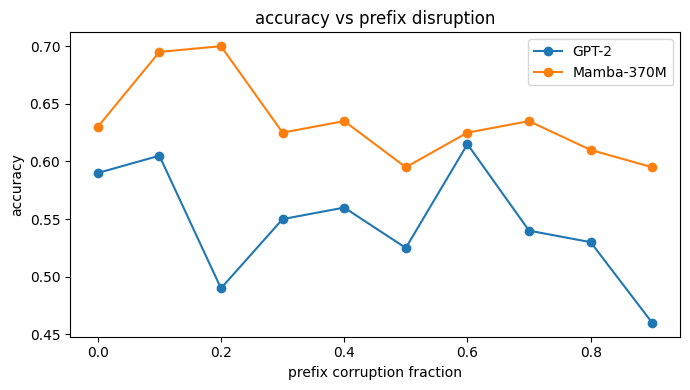

In [9]:
disrupt_res = {"GPT-2": {}, "Mamba-370M": {}}
for frac in FRACS:
    perturbed = [disrupt(t, frac) if frac > 0 else t for t, _ in test_pairs]
    pairs_p = list(zip(perturbed, [l for _, l in test_pairs]))
    disrupt_res["GPT-2"][frac] = eval_fewshot(
        gpt2, gpt2_tok, pairs_p, train_pairs, 4, DEVICE
    )
    disrupt_res["Mamba-370M"][frac] = eval_fewshot(
        mamba, mamba_tok, pairs_p, train_pairs, 4, DEVICE
    )
    print(
        f"frac={frac:.1f} gpt2={disrupt_res['GPT-2'][frac]:.4f} mamba={disrupt_res['Mamba-370M'][frac]:.4f}"
    )

plot_lines(
    disrupt_res,
    "prefix corruption fraction",
    "accuracy",
    "accuracy vs prefix disruption",
)

#### Adversarial label injection

Each review is perturbed with one of four injection strategies (`clean`, `adv_pos`, `adv_neg`, `adv_suf`) and 4-shot accuracy is compared across strategies with a grouped bar chart.

[clean] gpt2=0.5500 mamba=0.6750
[adv_pos] gpt2=0.5500 mamba=0.5600
[adv_neg] gpt2=0.5600 mamba=0.5350
[adv_suf] gpt2=0.5300 mamba=0.4850


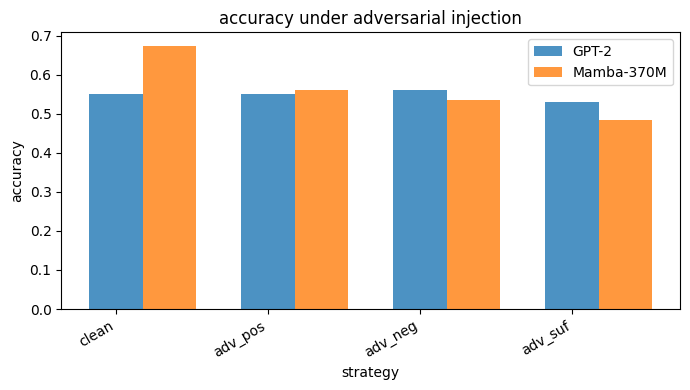

In [10]:
inject_res = {"GPT-2": {}, "Mamba-370M": {}}
for name, fn in INJ.items():
    perturbed = [fn(t) for t, _ in test_pairs]
    pairs_p = list(zip(perturbed, [l for _, l in test_pairs]))
    inject_res["GPT-2"][name] = eval_fewshot(
        gpt2, gpt2_tok, pairs_p, train_pairs, 4, DEVICE
    )
    inject_res["Mamba-370M"][name] = eval_fewshot(
        mamba, mamba_tok, pairs_p, train_pairs, 4, DEVICE
    )
    print(
        f"[{name}] gpt2={inject_res['GPT-2'][name]:.4f} mamba={inject_res['Mamba-370M'][name]:.4f}"
    )

fig, ax = plt.subplots(figsize=(7, 4))
xticks = None
for i, (name, kv) in enumerate(inject_res.items()):
    xs = list(kv.keys()) 
    ys = list(kv.values())
    ax.bar(
        [xi + i * 0.35 for xi in range(len(xs))],
        ys,
        width=0.35,
        label=name,
        alpha=0.8,
    )
    xticks = xs
ax.set_xticks(range(len(xticks or [])))
ax.set_xticklabels([str(k) for k in (xticks or [])], rotation=30, ha="right")
ax.set(xlabel="strategy", ylabel="accuracy", title="accuracy under adversarial injection")
ax.legend()
plt.tight_layout()
plt.show()

#### Gate weight profile

Loads the trained `TheoreticalMamba` checkpoint and averages gate weights $G_{i,l+1}$ over 200 random prompt sequences. The bar chart shows how attention decays with distance from the query, confirming the recency bias predicted by the theory.

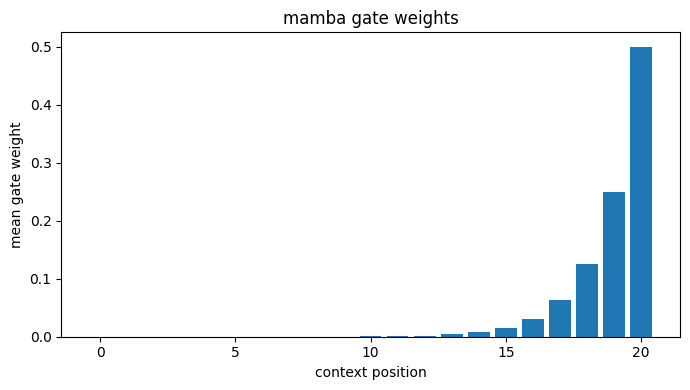

In [11]:
ckpt = OUTDIR / "results/mamba_theoretical.pt"
if ckpt.exists():
    from src.models.mamba_theoretical import TheoreticalMamba

    model_th = TheoreticalMamba(16).to(DEVICE)
    model_th.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model_th.eval()
    tasks = [BinaryICLTask(16, DEVICE) for _ in range(10)]
    gates = []
    with torch.no_grad():
        for _ in range(200):
            task = random.choice(tasks)
            x_c, y_c = task.sample(20)
            x_q, _ = task.sample(1)
            ctx = torch.cat([x_c.T, y_c.unsqueeze(0)], 0)
            qcol = torch.cat([x_q.T, torch.zeros(1, 1, device=DEVICE)], 0)
            P = torch.cat([ctx, qcol], -1).unsqueeze(0)
            gates.append(
                model_th._compute_gates(model_th.w, P).squeeze(0).cpu().numpy()
            )
    mean_g = np.mean(gates, axis=0)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(range(len(mean_g)), mean_g)
    ax.set(
        xlabel="context position", ylabel="mean gate weight", title="mamba gate weights"
    )
    plt.tight_layout()
    plt.show()